# Rationalising Priors

- Implementing my big algorithm for choosing priors and then fitting models with different values of k and combinations of the prior frequencies.
- Then implement the model comparison with Occam penalty. 
- Use validation for model selection and test set for testing.

In [ ]:
import pandas as pd
from astropy.time import Time
import matplotlib.pyplot as plt
import celerite2
import numpy as np
from celerite2 import terms
from scipy.optimize import minimize
from prettytable import PrettyTable


# Importing data
data = pd.read_csv(r"./Data/sind_all.txt", sep='\s', header = 1)
data.columns = ["JD", "sind"]
data['JD'] = data['JD'] + 2400000.0 # this file drops the 24 prefix
time_obj = Time(data["JD"].to_numpy(), format='jd', scale='tdb')
data["year"] = time_obj.jyear
data['datetime'] = time_obj.to_datetime(timezone=None)
data = data.set_index('datetime')

# Split the data
train_df, valid_df, test_df = split_df(data)


# No need to down sample the dataset here. yay!
def split_df(df, train_split=0.22, valid_split=0.59):
    n = len(df)
    train_idx = round(train_split * n)
    valid_idx = round((train_split + valid_split) * n)
    return df.iloc[:train_idx].copy(), df.iloc[train_idx:valid_idx].copy(), df.iloc[valid_idx:].copy()


C:\Users\Joey\AppData\Local\Temp\ipykernel_90832\510679148.py:12: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(r"./Data/sind_all.txt", sep='\s', header = 1)


- Plot Lomb-Scargle and add FAPs

In [2]:
def FAP(N, M, P):
    '''
    N is the number of datapoints in the time series from which the LS periodogram is derived.
    M is the number of independent frequencies M approx T x (fmax-fmin), where T is the number of years of data you have
    P is the power for which the FAP is desired.
    '''
    return  1 - ((1 - (1 - (2*P / (N-1)))** ((N-3)/2)) ** M)

def invFAP(N, M, FAP):
    '''
    Returns the power threshold corresponding to a given FAP level.
    Inverse of FAP function above.
    '''
    single_trial = 1 - (1 - FAP) ** (1/M)
    P = (N-1)/2 * (1 - single_trial ** (2/(N-3)))
    
    return P


0.6746139079242098
1397 46.653040862424064
[0.0239887  0.02537258 0.02764598]


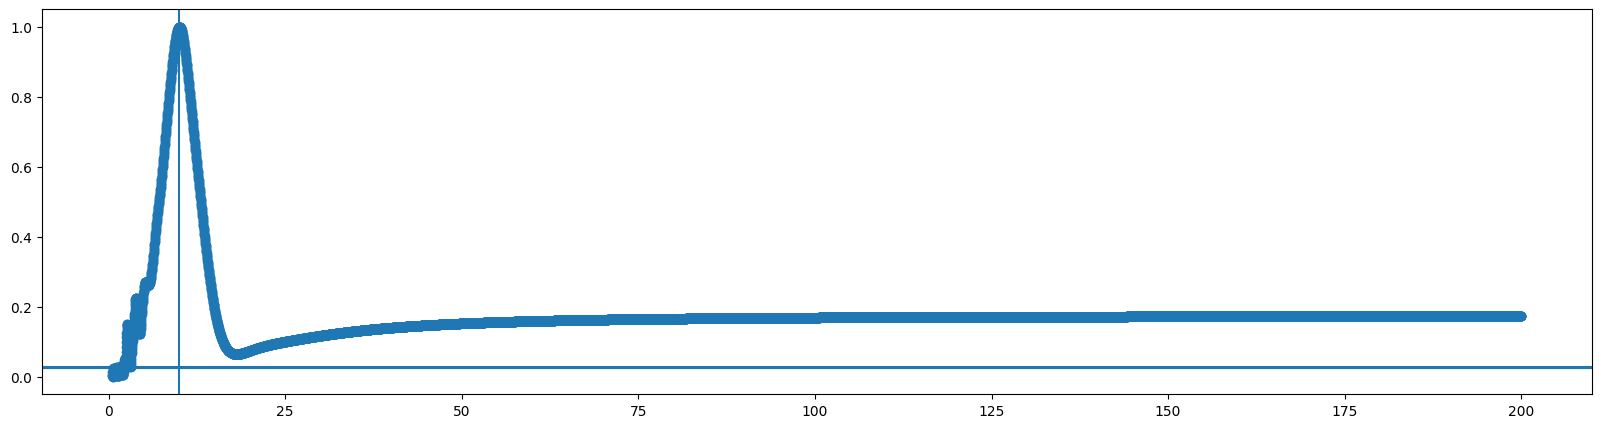

The best period is 10.017101710171017 years


In [ ]:
# Lomb scargle 
# Lomb-Scargle finds periodic signals in unevnly sampled time series.
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks

# Define freq range
min_period = 0.5
max_period = 200
n_periods = 10000
periods = np.linspace(min_period, max_period, n_periods)
freq = 1 / periods

ls = LombScargle(train_df['year'], train_df['sind'])
power = ls.power(freq)

# # Normalise the powers to frac of max to aid in peak finding
max_power = max(power)
power /= max_power

noise = np.percentile(power, 75)
print(max_power)

# Find the Lomb-Scargle peak
peaks, properties = find_peaks(power, height = 0., prominence= 5 * noise) # peaks is an array of the indices of the input arrays with the peaks
peak_periods = periods[peaks]

# Things for calculating the FAP
N = len(train_df)
T = train_df['year'].max() - train_df['year'].min()
M = T * (1/min_period - 1/max_period)
print(N,M)

# FAPs of note
FAPs = np.array([10, 5, 1]) / 100
power_invFAPs = ls.false_alarm_level(FAPs, method = 'bootstrap') / max_power
# power_invFAPs = invFAP(N = N, M = M, FAP = FAPs)
# power_invFAPs = 2 * power_invFAPs / (N - 1)  # convert HB units to standard
# power_invFAPs /= max_power
print(power_invFAPs)

# plot the thing
fig, ax = plt.subplots(1, figsize = (20,5))
ax.scatter(periods,power)
for peak_period in peak_periods:
    ax.axvline(peak_period)
for power_invFAP in power_invFAPs:
    ax.axhline(power_invFAP)
plt.show()

# print the best period
best_period = periods[np.argmax(power)]
print(f"The best period is {best_period} years")


- Generate fake data to test the LS thing
    - Generate between 1 and 3 sine waves
    - Randomly sample values based on the sum
    - Perform analysis to verify

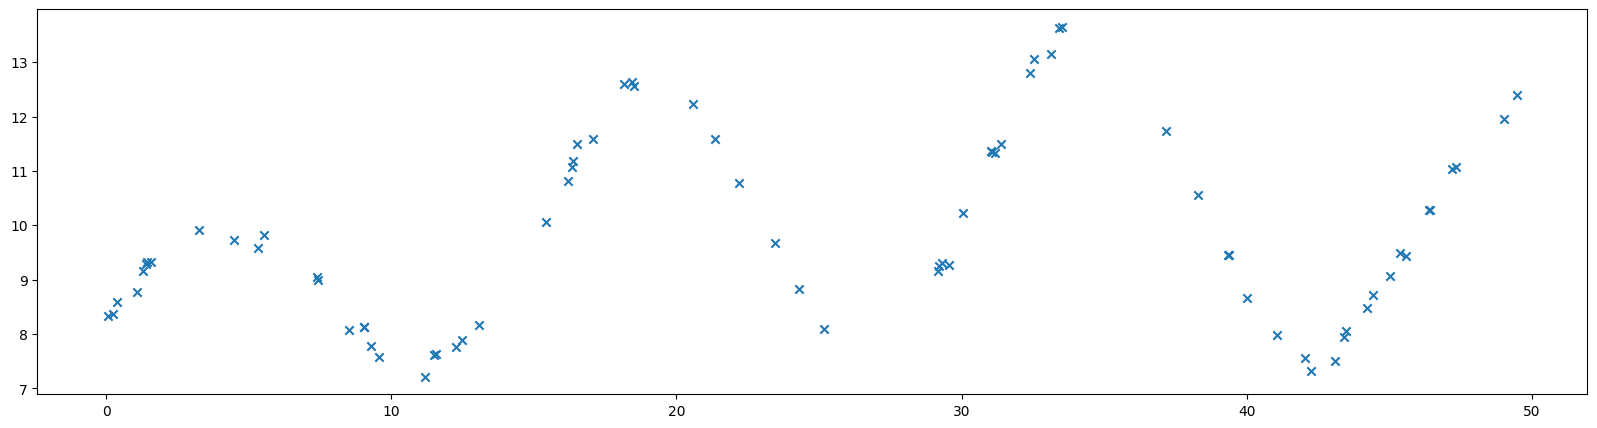

In [88]:
import random

def generate_toy_signal(k = 3, time_range=30, seasonal=1, plot = False, mult = 10):
    '''
    Generates a fake signal so we can see if the periodogram is useful for identifying the priors.
    There are three possible ranges of the data. Short; medium; long.
    Short on order of days: 1/10 years
    Mid on order of decade: 10-20 ish years
    Long (Gleissman) on order of century: 100-200 years

    Chooses k out of 3 of them

    Time range is the number of years across which observations were taken
    Seasonal simulates observation gaps annually; seasonal = 1 takes all observations

    returns
    t in years
    '''
    bounds = {
        "short": ((10/365, 1), (0.05, 0.2)),
        "mid": ((7, 20),(0.5,10)),
        "long": ((100, 200),(0.1, 0.4))
    }

    # Choose the bounds
    chosen_bounds = dict(random.sample(list(bounds.items()), k=k))

    shortest_period = min(lo for (lo, hi), (blo, bhi) in chosen_bounds.values()) 
    dt = shortest_period * mult  # nyquist safe 

    # Chosen keys
    keys = chosen_bounds.keys()

    # Choose the periods
    periods = [np.random.uniform(lo,hi) for (lo, hi), (blo,bhi) in chosen_bounds.values()]

    # Choose the concomitant amplitudes
    amps = [np.random.uniform(blo, bhi) for (lo, hi), (blo, bhi) in chosen_bounds.values()]

    n_points = int(time_range / dt)
    t = np.sort(np.random.uniform(0, time_range, size=n_points))
    
    if seasonal < 1:
        t = t[np.mod(t, 1.0) < 0.6]

    # Find the y given by the chosen items
    components = {
        key: amp * np.sin(2 * np.pi * t / period + np.random.uniform(0, 2 * np.pi)) + np.random.normal(0,5)
        for key, period, amp in zip(keys, periods, amps)
    }

    if "long" in components and "mid" in components:
        y = (1 + components["long"]) * components["mid"]
        if "short" in components:
            y += components['short']
    else:
        y = sum(components.values())
    
    if plot:
        fig, ax = plt.subplots(figsize=(20,5))
        ax.scatter(t,y, marker = 'x')
    return t, y, dict(zip(keys, zip(periods, amps)))

t, y, signal_data = generate_toy_signal(plot= True, time_range= 50, mult = 15, seasonal= 0.8)

- Now we can use this data to be able to write a function that uses the periodogram and model comparison to figure out how many peaks there are to use as priors.
- Since FAPs are not working, if there are more than 3 peaks we can select them by the strongest powers.
- Let us functionise the Lomb-Scargle periodogram code.

In [ ]:
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks

def identify_peaks(t=None,y=None,df = None, plot = True, min_period = 0.5, max_period = 200, n_periods = 10000, normalise = True, max_peaks = 3):
    '''
    Identifies the peaks available to be used as priors in a GPR fitting.
    Takes in the DF, calculates the LSP, identifies the peaks and the number thereof.
    It uses simple heuristics to classify them into long, mid, and short ranges.

    Params
    plot: plots LSP if True
    min_period, max_period in years
    n_periods to set the resolutio 


    Returns
    The peak periods and their concomitant ranges.
    '''
    # Define freq range
    periods = np.linspace(min_period, max_period, n_periods)
    freq = 1 / periods

    if df is not None:
        ls = LombScargle(df['year'], df['sind'])

    elif t is not None and y is not None:
        ls = LombScargle(t, y)

    else:
        raise ValueError("Please define either the df, or t and y")
    
    # Get the powers for the corresponding frequencies
    powers = ls.power(freq)

    # Normalise the powers to frac of max for interpretability
    if normalise:
        max_power = max(powers)
        powers /= max_power

    # Define the noise floor against which to compare the peaks
    noise = np.percentile(power, 75)
    
    # Find the Lomb-Scargle peaks
    peak_idxs, properties = find_peaks(powers, height = 0., prominence= 5 * noise) # peaks is an array of the indices of the input arrays with the peaks
    peak_periods = periods[peak_idxs]
    peak_powers = powers[peak_idxs] # the concomitant powers

    # Counts the number of peaks
    n_peaks =  len(peak_periods)
    if n_peaks > max_peaks: # must choose the top three peaks
        # more than three peaks must be noise
        top_idx = np.argsort(peak_powers)[-1 * max_peaks:] # takes top three
        peak_periods = peak_periods[top_idx]
        peak_powers = peak_powers[top_idx]
        n_peaks = max_peaks

    ## Identify which cycle range the periods are in
    peak_info = {} # the dictionary to return with peaks in "range": length
    # 1 significant peak
    if n_peaks == 1:
        peak_period = peak_periods[0]
        if peak_period <= 1: # if less than one year it is the short (rotation) cycle
            peak_info['short'] = peak_period
        elif peak_period <= 50: # this is probably the mid (stellar/Schwabe) cycle
            peak_info['mid'] = peak_period
        else: # highly unlikely to be physical
            pass # returns empty peak_info to indicate that we should randomise priors and flag a warning
    
    # 2 significant peaks
    elif n_peaks == 2:
        shorter_period = min(peak_periods)
        longer_period = max(peak_periods)

        # best case: they fit in the short and mid ranges
        if 0 <= shorter_period <= 1 and  1 < longer_period <= 50:
            peak_info['short'] = shorter_period
            peak_info['mid'] = longer_period
        # elif one short one long
        elif 0 <= shorter_period <= 1 and 50 < longer_period:
            peak_info['short'] = shorter_period
            peak_info['long'] = longer_period
        #elif one mid one long
        elif 1 < shorter_period <= 50 and 50 < longer_period:
            peak_info['mid'] = shorter_period
            peak_info['long'] = longer_period
        # elif they are both in the short cycle range; unlikely contingency
        elif 0 <= shorter_period <= 1 and  0 <= longer_period <= 1: 
            peak_info['short'] = np.mean(shorter_period, longer_period)
        # elif they are both in the mid cycle range; unlikely contingency
        elif 0 <= shorter_period <= 1 and  0 <= longer_period <= 1: 
            peak_info['mid'] = np.mean(shorter_period, longer_period)
        # else they would both be in the Gleissberg/long regime: unphysical return empty
        else:    
            pass
        
        

    # plot the thing
    fig, ax = plt.subplots(1, figsize = (20,5))
    ax.scatter(periods,power)
    for peak_period in peak_periods:
        ax.axvline(peak_period)
    for power_invFAP in power_invFAPs:
        ax.axhline(power_invFAP)
    plt.show()

    # print the best period
    best_period = periods[np.argmax(power)]
    print(f"The best period is {best_period} years")

    

- Now test this by running the generation and the identification consecutively repeatedly. Compare the peaks and alleged cycle ranges

- Create code that creates the three priors from every set.